In [1]:
import os
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END

from langchain_ollama import ChatOllama
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI

from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field

from langchain_core.messages import SystemMessage, HumanMessage
from langchain_classic.output_parsers import PydanticOutputParser, OutputFixingParser

import operator

load_dotenv()

True

In [18]:
class EvaluationSchema(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final Evaluation result.")
    feedback: str = Field(..., description="Feedback on the post")

base_parser = PydanticOutputParser(pydantic_object=EvaluationSchema)

## Initializing LLMs

# Using models known to work well with structured output
ollama_gpt = ChatOllama(model='gpt-oss:120b-cloud')
generate_llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
evaluation_llm = ChatGroq(model="qwen/qwen3-32b")
optimizer_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


## Creating model object structured output for sentiment analysis
schema_parser = OutputFixingParser.from_llm(parser=base_parser, llm=evaluation_llm)

            - This is version {state['iteration']} of the tweet generation process.

In [22]:
class CreatePostState(TypedDict):
    topic: str = Field(description="Topic of the post")
    generated_post: str = Field(description="generated post for the given topic")
    feedback: str = Field(description="Feedback on the generated post")
    evaluation: Literal['approved', 'needs_improvement'] = Field(description="Evaluation of the generated post")
    iteration: int = Field(description="Iteration number for the generation and evaluation process")
    max_iterations: int = Field(description="Maximum number of iterations for the generation and evaluation process")

    feedback_history: Annotated[list[str], operator.add]
    tweet_history: Annotated[list[str], operator.add]

# Func_1
def generate_post(state: CreatePostState) -> CreatePostState:

    prompt = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""Write a short, original and hilarious tweet on the topic of {state['topic']}.
            Rules:
            - Do not use question answer format.
            - The tweet must be less than 280 characters.
            - Use observational humor, irony, sarcasm or cultural references.
            - Think in memes line, punchlines or relatable takes.
            - Use simple day to day english language.
    """)
        ]
    
    response = generate_llm.invoke(prompt).content

    return {'generated_post': response, 'tweet_history': [response]}

# Func_2
def evaluate_post(state: CreatePostState) -> CreatePostState:

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['generated_post']}"

    Use the criteria below to evaluate the tweet:

    1. Originality - Is this fresh, or have you seen it a hundred times before?  
    2. Humor - Did it genuinely make you smile, laugh, or chuckle?  
    3. Punchiness - Is it short, sharp, and scroll-stopping?  
    4. Virality Potential - Would people retweet or share it?  
    5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

    Auto-reject if:
    - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
    - It exceeds 280 characters
    - It reads like a traditional setup-punchline joke
    - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

    ### Respond ONLY in structured format:
    - evaluation: "approved" or "needs_improvement"  
    - feedback: One paragraph explaining the strengths and weaknesses 
    """)
    ]
    llm_output = evaluation_llm.invoke(messages).content
    response = schema_parser.invoke(llm_output)

    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

# Func_3
def optimize_post(state: CreatePostState) -> CreatePostState:

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
    Improve the tweet based on this feedback:
    "{state['feedback']}"

    Topic: "{state['topic']}"
    Original Tweet:
    {state['generated_post']}

    Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
    """)
        ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'generated_post': response, 'iteration': iteration, 'tweet_history': [response]}

# Func_4
def check_decision(state: CreatePostState) -> CreatePostState:

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return "approved"
    else:
        return "needs_improvement"


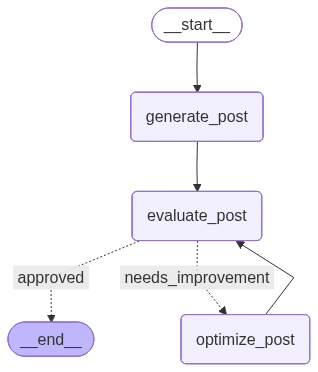

In [23]:
# Define state graph
graph = StateGraph(CreatePostState)

# add nodes
graph.add_node('generate_post', generate_post)
graph.add_node('evaluate_post', evaluate_post)
graph.add_node('optimize_post', optimize_post)

# add edges
graph.add_edge(START, 'generate_post')
graph.add_edge('generate_post', 'evaluate_post')

graph.add_conditional_edges('evaluate_post', check_decision, {"approved": END, "needs_improvement": "optimize_post"})
graph.add_edge('optimize_post','evaluate_post')

#compile
workflow = graph.compile()

# visualize
workflow

In [24]:
initial_state = {
    'topic':"Raghav Chadha",
    'iteration': 0,
    'max_iterations': 5,
}

workflow.invoke(initial_state)

{'topic': 'Raghav Chadha',
 'generated_post': '"Raghav Chadha\'s rise in politics is like my aunt\'s gossip circle - swift, surprising, and leaving everyone talking #RaghavChadha"',
 'feedback': "The tweet earns approval for its clever metaphor linking political rise to a gossip circle, which is both humorous and relatable. The humor lands effectively by juxtaposing a public figure with a mundane, relatable scenario ('aunt's gossip circle'), creating a subtle punch through irony. It’s punchy at 158 characters, avoids setup-punchline tropes, and ends cleanly with a hashtag. Viral potential exists due to its shareable contrast and niche appeal (political satire + family humor). The minor weakness is the analogy isn’t entirely novel—family-based humor is common—but the specificity of 'aunt's gossip circle' adds freshness. No auto-reject triggers, and the format adheres to guidelines.",
 'evaluation': 'approved',
 'iteration': 0,
 'max_iterations': 5,
 'feedback_history': ["The tweet earns

In [28]:
initial_state = {
    'topic':"Our Prime Minister - The Vishwa Guru",
    'iteration': 0,
    'max_iterations': 5,
}

workflow.invoke(initial_state)

{'topic': 'Our Prime Minister - The Vishwa Guru',
 'generated_post': '"Our PM, the Vishwa Guru, teaching the world how to do yoga... meanwhile, back home, his ministers are doing \'bhajans\' on opposition\'s exit doors #VishwaGuru"',
 'feedback': "The tweet effectively balances originality with humor, using a sharp political metaphor (international yoga vs. domestic 'bhajans') and a punchy hashtag. It’s concise, visually arresting, and leverages trending political discourse for virality. Minimal weaknesses include niche cultural references, but this enhances resonance within the target audience.",
 'evaluation': 'approved',
 'iteration': 0,
 'max_iterations': 5,
 'feedback_history': ["The tweet effectively balances originality with humor, using a sharp political metaphor (international yoga vs. domestic 'bhajans') and a punchy hashtag. It’s concise, visually arresting, and leverages trending political discourse for virality. Minimal weaknesses include niche cultural references, but thi